<a href="https://colab.research.google.com/github/MarioDLCruz/PolisemiaV1/blob/main/umap1k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import umap

In [ ]:
import pandas as pd

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
import numpy as np

In [ ]:
umap.UMAP

umap.umap_.UMAP

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/tokens1k.csv'
df = pd.read_csv(file_path)

In [ ]:
df

,token,id_tweet,region,id_vector,vector,x,y
0,[CLS],0,Jalisco,0,"[0.0132701714, -0.017905375, -0.00618814072, -...",17.480507,0.133477
1,Jalisco,0,Jalisco,1,"[0.00420953473, -0.0329080522, 0.0130279278, -...",-2.929577,-4.723766
2,_GEO,0,Jalisco,2,"[-0.0135559319, -0.00135187013, 0.0171045307, ...",-8.066501,4.153235
3,_USR,0,Jalisco,3,"[-0.0358271115, -0.0446212329, 0.0243038628, -...",-2.334858,5.031593
4,Se,0,Jalisco,4,"[0.0286497883, -0.0264977496, 0.0178820007, -0...",2.594655,0.177844
...,...,...,...,...,...,...,...
30348,##I,999,Mexico_City,19,"[0.00951175019, 0.00765987625, 0.0700742528, -...",5.272044,0.524495
30349,##f,999,Mexico_City,20,"[-0.00696010841, -0.0221082475, 0.00697800005,...",6.400532,1.019043
30350,😭,999,Mexico_City,21,"[-0.0522314981, -0.0729229525, -0.0257079042, ...",8.825209,4.891585
30351,_URL,999,Mexico_City,22,"[-0.0176484715, -0.091482833, -0.000317632803,...",7.781148,7.773776


In [ ]:
reducer = umap.UMAP()

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd


In [ ]:
import numpy as np
import re

def parse_vector(v_str):
    # Elimina los corchetes si existen y divide por espacios
    clean_str = re.sub(r'[\[\]]', '', v_str)
    # Convierte en lista de floats
    return np.fromstring(clean_str, sep=' ')

# Aplica la conversión
df['vector'] = df['vector'].apply(parse_vector)


In [ ]:
from sklearn.preprocessing import StandardScaler
import umap

X = np.vstack(df['vector'].values)
X/=np.linalg.norm(X, axis=1).reshape(-1, 1)
X.shape
embedding = umap.UMAP(metric="cosine").fit_transform(X)


In [ ]:
np.linalg.norm(X[0])

np.float64(1.0)

In [ ]:
X.shape

(30353, 512)

In [ ]:
embedding.shape

(30353, 2)

In [ ]:
import matplotlib.pyplot as plt

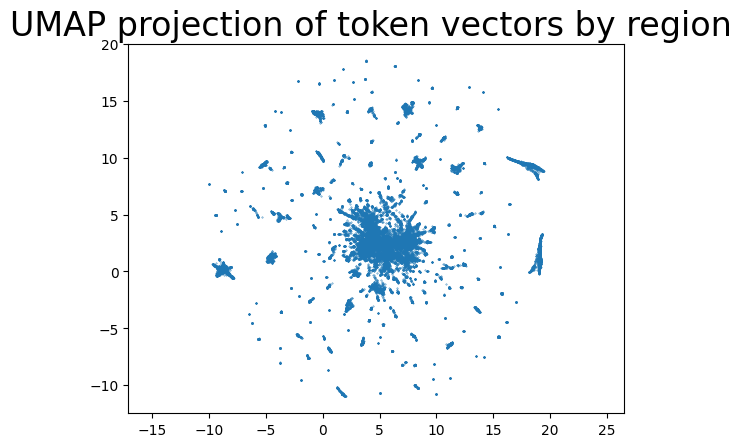

In [ ]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=.1,
    )

    #c=[palette[i] for i in region_indices])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of token vectors by region ', fontsize=24);

In [ ]:
df["x"] = embedding[:, 0]
df["y"] = embedding[:, 1]
df[["token", "region", "x", "y"]]


,token,region,x,y
0,[CLS],Jalisco,17.480507,0.133477
1,Jalisco,Jalisco,-2.929577,-4.723766
2,_GEO,Jalisco,-8.066501,4.153235
3,_USR,Jalisco,-2.334858,5.031593
4,Se,Jalisco,2.594655,0.177844
...,...,...,...,...
30348,##I,Mexico_City,5.272044,0.524495
30349,##f,Mexico_City,6.400532,1.019043
30350,😭,Mexico_City,8.825209,4.891585
30351,_URL,Mexico_City,7.781148,7.773776


In [ ]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="region",
    hover_data=["token", "region", "id_tweet"],
    title="UMAP projection of token vectors by region",
    width=1000,
    height=700
)


fig.update_traces(marker=dict(size=3, opacity=0.6), selector=dict(mode='markers'))
fig.update_layout(legend_title="Región", title_x=0.5)

fig.show()


In [ ]:
from google.colab import files
fig.write_html("umap_tokens.html")
files.download("umap_tokens.html")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

reducer3d = umap.UMAP(n_components=3, metric="cosine")
embedding_3d = reducer3d.fit_transform(X)

# Guardamos las nuevas dimensiones
df["x"] = embedding_3d[:, 0]
df["y"] = embedding_3d[:, 1]
df["z"] = embedding_3d[:, 2]


In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="x",
    y="y",
    z="z",
    color="region",  # O puedes usar "cluster"
    hover_data=["token"],
    opacity=0.6
)
fig.update_traces(marker=dict(size=1))
fig.update_layout(title="UMAP 3D projection of token vectors")
fig.show()
fig.write_html("umap_3d.html")


In [ ]:
from google.colab import files
files.download("umap_3d.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-15-2172382678.py:6: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



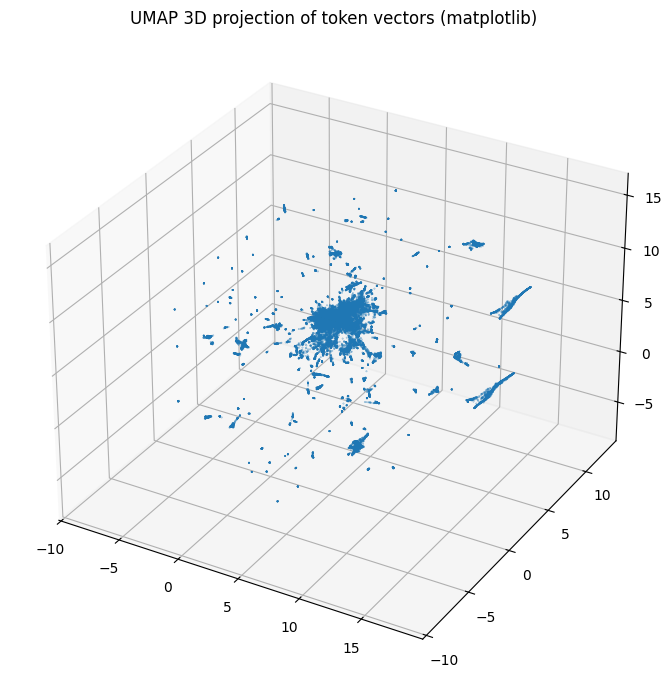

In [ ]:

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df["x"],
    df["y"],
    df["z"],

    cmap="tab20",
    s=.1,
    alpha=0.6
)

ax.set_title("UMAP 3D projection of token vectors (matplotlib)")
plt.tight_layout()
plt.show()


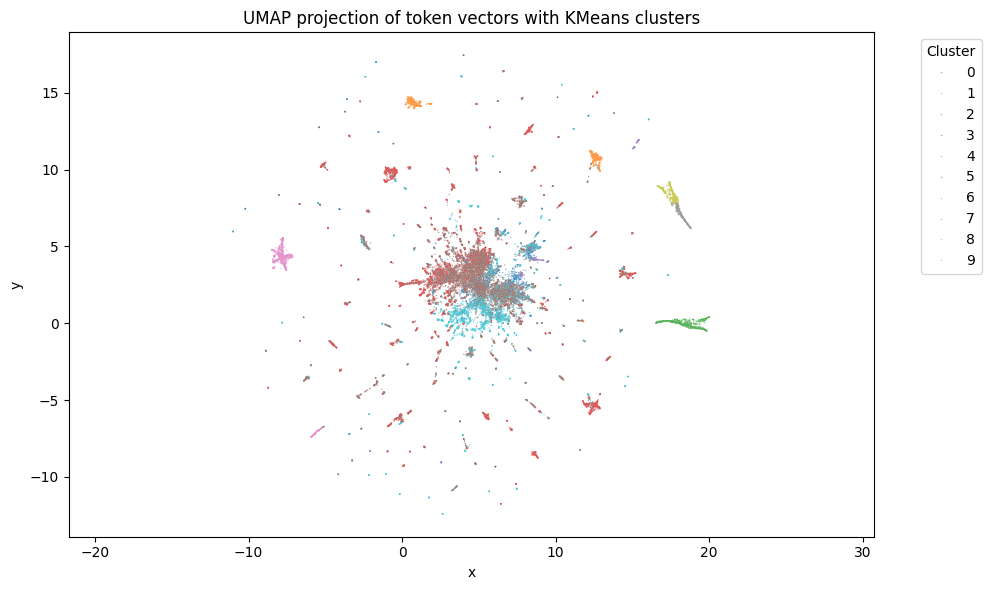

In [ ]:

from sklearn.cluster import KMeans
import seaborn as sns


# Aplicar KMeans
kmeans = KMeans(n_clusters=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Visualizar sobre UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df["x"],
    y=df["y"],
    hue=df["cluster"],
    palette="tab10",
    s=1,
    alpha=0.6,
    legend="full"
)
plt.title("UMAP projection of token vectors with KMeans clusters")
plt.gca().set_aspect("equal", "datalim")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [ ]:

from sklearn.preprocessing import StandardScaler

X_umap = df[["x", "y"]].values

eps = 0.1
db = DBSCAN(eps=eps, min_samples=3)
df["dbscan_cluster"] = db.fit_predict(X_umap)



In [ ]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="dbscan_cluster",
    title="DBSCAN clustering sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token","region","id_tweet"]
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(height=600)
fig.show()

In [ ]:
print("Número de Cústeres:", df["dbscan_cluster"].nunique())


Número de Cústeres: 316


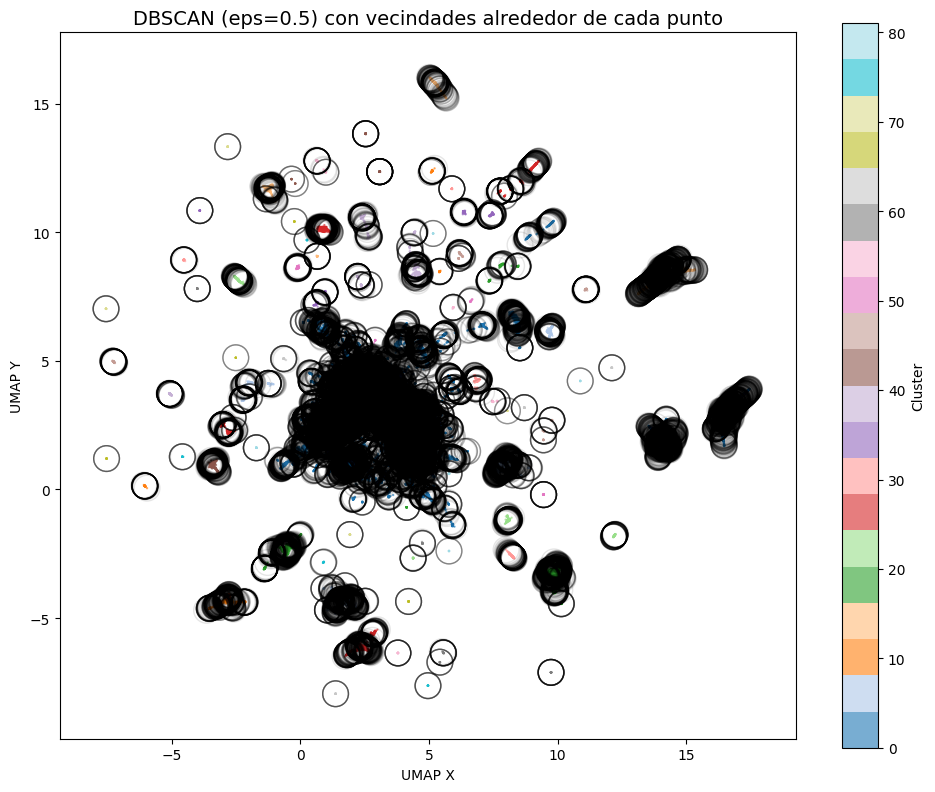

In [ ]:
plt.figure(figsize=(10, 8))

# Puntos coloreados por clúster
scatter = plt.scatter(
    df["x"], df["y"],
    c=df["dbscan_cluster"],
    cmap="tab20",
    s=.5,
    alpha=0.6
)

# Dibujar un círculo eps alrededor de cada punto
for x, y in X_umap:
    circle = plt.Circle((x, y), eps, color='black', fill=False, alpha=0.1)
    plt.gca().add_patch(circle)

plt.gca().set_aspect("equal", "box")
plt.title(f"DBSCAN (eps={eps}) con vecindades alrededor de cada punto", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.cluster import HDBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [ ]:
clusterer = HDBSCAN(min_cluster_size=10)
cluster_labels = clusterer.fit_predict(X_umap)

df["hdbscan_cluster"] = cluster_labels

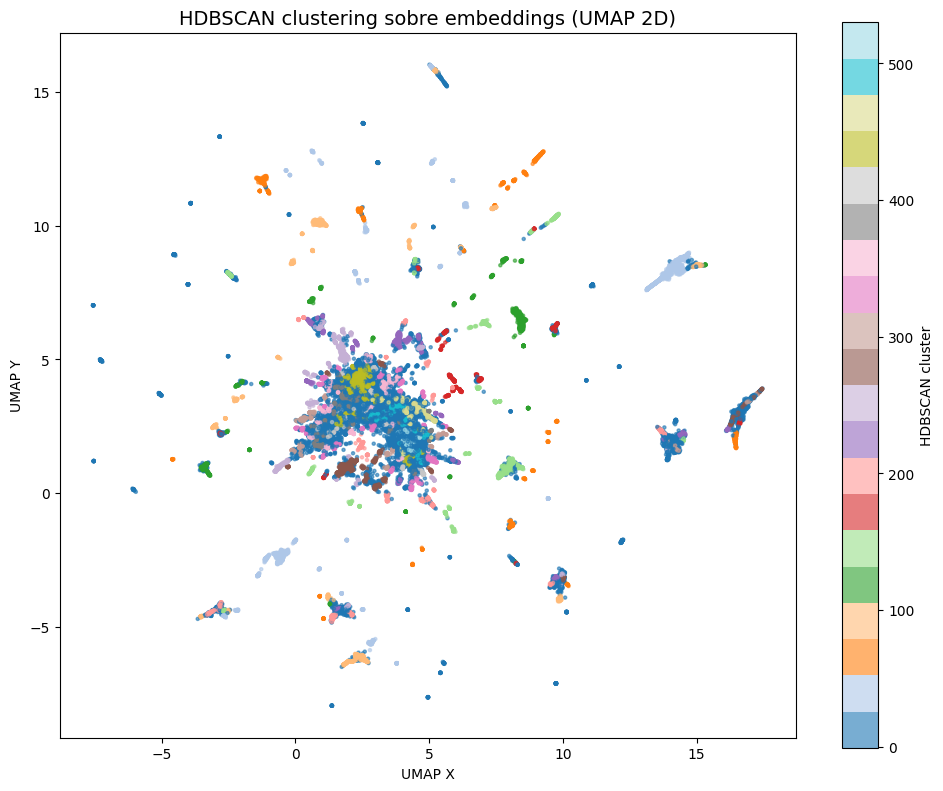

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["x"],
    df["y"],
    c=df["hdbscan_cluster"],
    cmap="tab20",
    s=5,
    alpha=0.6
)
plt.colorbar(scatter, label="HDBSCAN cluster")
plt.title("HDBSCAN clustering sobre embeddings (UMAP 2D)", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()


In [ ]:
print("Número de Cústeres:", df["hdbscan_cluster"].nunique())


Número de Cústeres: 532


In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="hdbscan_cluster",
    title="Clustering con HDBSCAN sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token", "region","id_tweet"]
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(height=600)
fig.show()
